In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings; warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("data/all_data_merged.csv", parse_dates=["DATE"])
df = df.sort_values(["DISTRICT", "DATE"]).reset_index(drop=True)

ohe = OneHotEncoder(sparse_output=False)
district_onehot = ohe.fit_transform(df[["DISTRICT"]])
X_base = df[["WEATHER_CONDITION","SPECIAL_DAY","DAY_OF_WEEK_NUM",
             "POPULATION","RAILWAY_STATIONS","BUS_STATIONS"]].values
X_raw = np.hstack([X_base, district_onehot])
y_raw = df["CONGESTION"].values.reshape(-1, 1)

sx, sy = MinMaxScaler(), MinMaxScaler()
Xs = sx.fit_transform(X_raw)
ys = sy.fit_transform(y_raw)

seq_len = 10
Xs_seq, ys_seq, districts_seq = [], [], []
for i in range(len(Xs) - seq_len):
    Xs_seq.append(Xs[i:i+seq_len])
    ys_seq.append(ys[i+seq_len])
    districts_seq.append(df["DISTRICT"].iloc[i+seq_len])
Xs_seq, ys_seq, districts_seq = np.array(Xs_seq), np.array(ys_seq), np.array(districts_seq)

In [3]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_dim=2, n_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_dim, n_layers, batch_first=True)
        self.out = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        h, _ = self.lstm(x)
        return self.out(h[:, -1, :])

def flatten_weights(model):
    return np.concatenate([p.detach().cpu().numpy().ravel() for p in model.parameters()])

def unflatten_weights(model, vec):
    idx = 0
    for p in model.parameters():
        numel = p.numel()
        chunk = vec[idx:idx+numel].reshape(p.shape)
        p.data.copy_(torch.from_numpy(chunk))
        idx += numel

In [4]:
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from scipy.stats import qmc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
import numpy as np

def expected_improvement(X, gp, y_best, xi=0.01):
    mu, sigma = gp.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    with np.errstate(divide='warn'):
        imp = y_best - mu - xi
        Z = np.divide(imp, sigma, out=np.zeros_like(imp), where=sigma!=0)
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei.ravel()

In [5]:
def make_fitness(X_train, y_train, device="cpu"):
    model = LSTMRegressor(n_features=X_train.shape[-1], hidden_dim=2, n_layers=1).to(device)
    dim = sum(p.numel() for p in model.parameters())
    def fitness(w):
        unflatten_weights(model, np.array(w))
        Xb = torch.tensor(X_train, dtype=torch.float32).to(device)
        yb = torch.tensor(y_train, dtype=torch.float32).to(device)
        preds = model(Xb).squeeze()
        loss = nn.L1Loss()(preds, yb.squeeze()).item()
        return loss
    return fitness, dim, model

fitness, dim, model = make_fitness(Xs_seq, ys_seq)

In [6]:
def manual_bayes_optimize_ei(fitness, dim, n_init=8, n_iter=30, param_low=-1, param_high=1, random_state=42, search_grid_size=1200, verbose=True):
    np.random.seed(random_state)
    sampler = qmc.Sobol(d=dim, scramble=True, seed=random_state)
    X_samples = qmc.scale(sampler.random_base2(int(np.ceil(np.log2(n_init)))), param_low, param_high)[:n_init]
    y_samples = np.array([fitness(x) for x in X_samples])
    best_curve = [np.min(y_samples)]

    for iteration in range(n_iter):
                kernel = RBF(length_scale=np.ones(dim)) + WhiteKernel(noise_level=1e-1)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, random_state=random_state+iteration)
    with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            gp.fit(X_samples, y_samples)

    sampler_grid = qmc.Sobol(d=dim, scramble=True, seed=random_state+iteration)
    search_grid = qmc.scale(sampler_grid.random(search_grid_size), param_low, param_high)
    y_best = np.min(y_samples)
    ei = expected_improvement(search_grid, gp, y_best, xi=0.01)
    idx_next = np.argmax(ei)
    x_next = search_grid[idx_next]
    y_next = fitness(x_next)
    X_samples = np.vstack([X_samples, x_next])
    y_samples = np.append(y_samples, y_next)
    best_curve.append(np.min(y_samples))

    if verbose:
        print(f"Iter {iteration+1:2d} | Best Loss: {np.min(y_samples):.6f} | Current Loss: {y_next:.6f} | EI: {ei[idx_next]:.4f}")

    best_idx = np.argmin(y_samples)
    best_params = X_samples[best_idx]
    best_loss = y_samples[best_idx]
    return best_params, best_loss, X_samples, y_samples, np.array(best_curve)

In [7]:
best_params, best_loss, all_X, all_y, best_curve = manual_bayes_optimize_ei(
    fitness, dim, 
    n_init=8, n_iter=30, 
    param_low=-1, param_high=1, 
    random_state=42,
    search_grid_size=1200
)
unflatten_weights(model, best_params)
print(f"Best loss found: {best_loss:.6f}")

Iter 30 | Best Loss: 0.203141 | Current Loss: 0.692553 | EI: 0.0344
Best loss found: 0.203141


In [9]:
results = []
districts = np.unique(districts_seq)

for district in districts:
    idxs = districts_seq == district
    X_d = Xs_seq[idxs]
    y_d = ys_seq[idxs]

    if len(X_d) == 0:
        continue

    Xb = torch.tensor(X_d, dtype=torch.float32)
    with torch.no_grad():
        preds = model(Xb).squeeze().numpy()
    preds_inv = sy.inverse_transform(preds.reshape(-1, 1))
    y_true_inv = sy.inverse_transform(y_d.reshape(-1, 1))

    mse = mean_squared_error(y_true_inv, preds_inv)
    mae = mean_absolute_error(y_true_inv, preds_inv)
    std_pred = preds_inv.std()
    std_true = y_true_inv.std()
    results.append({
        "District": district,
        "MSE": mse,
        "MAE": mae,
        "Pred Std": std_pred,
        "True Std": std_true
    })

df_results = pd.DataFrame(results)
sorted_df = df_results.sort_values("MSE")

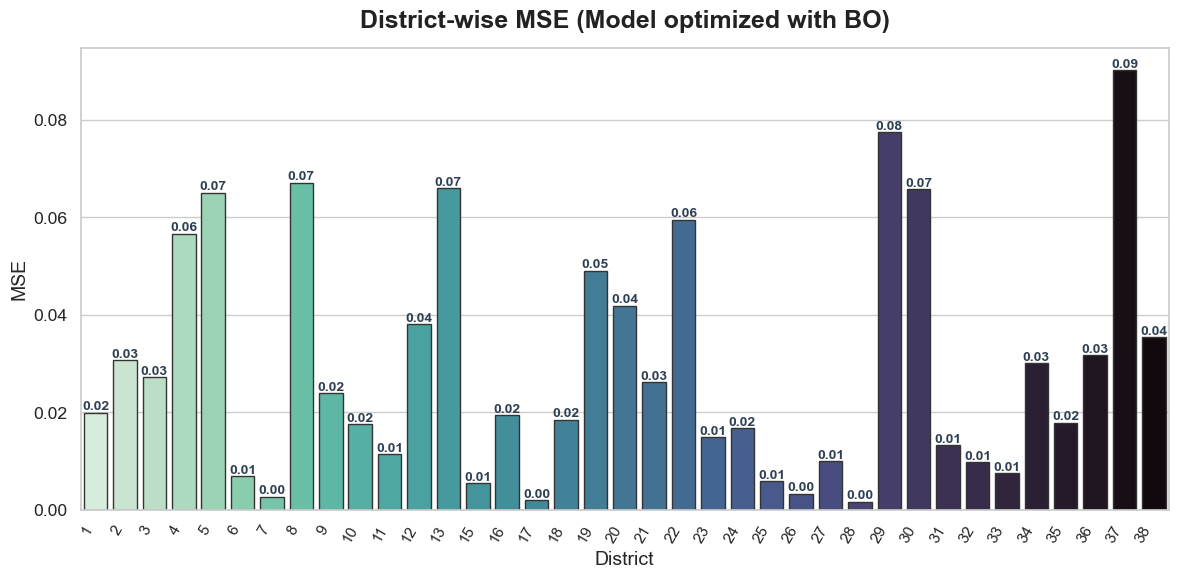

In [10]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.figure(figsize=(12, 6))
bar = sns.barplot(x="District", y="MSE", data=sorted_df, palette="mako_r", edgecolor=".2")
plt.title("District-wise MSE (Model optimized with BO)", weight="bold", fontsize=18, color="#222222", pad=15)
plt.ylabel("MSE", fontsize=14)
plt.xlabel("District", fontsize=14)
plt.xticks(rotation=60, ha="right", fontsize=11)
plt.tight_layout()
for p in bar.patches:
    bar.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                 ha="center", va="bottom", fontsize=10, color="#2e4053", weight="bold")
plt.show()

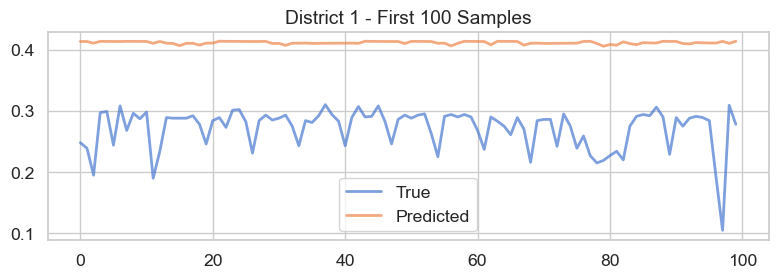

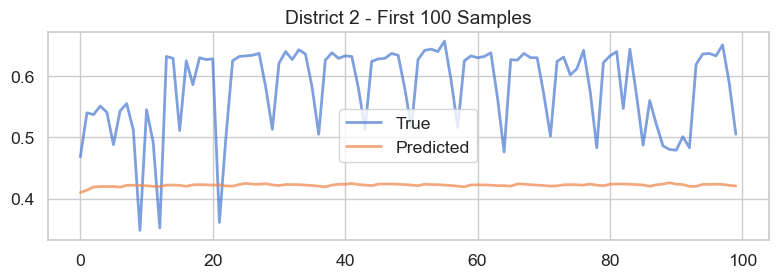

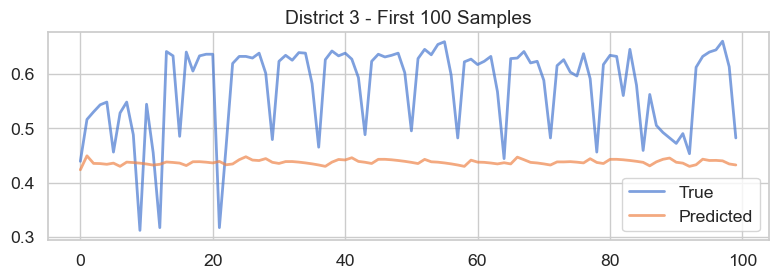

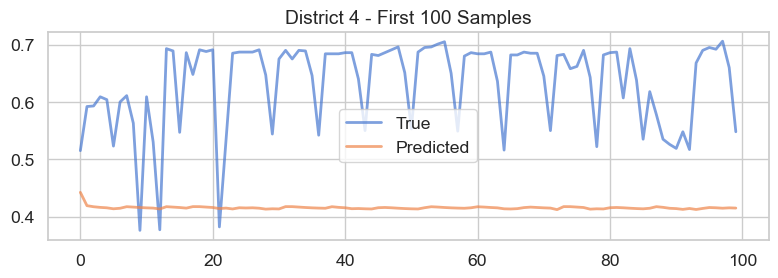

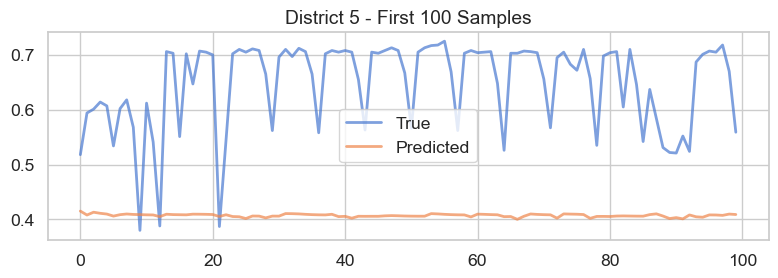

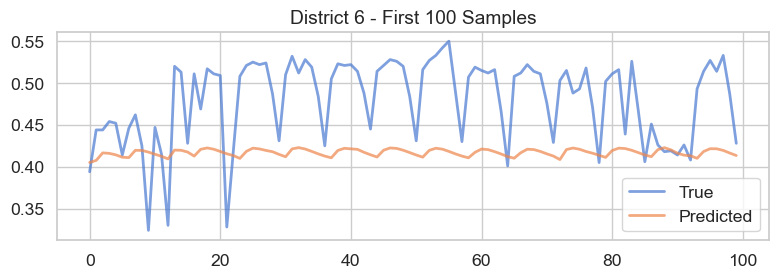

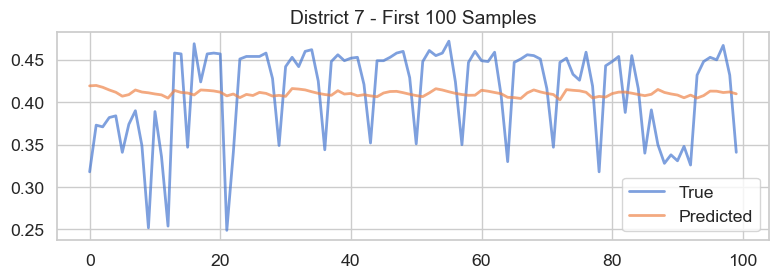

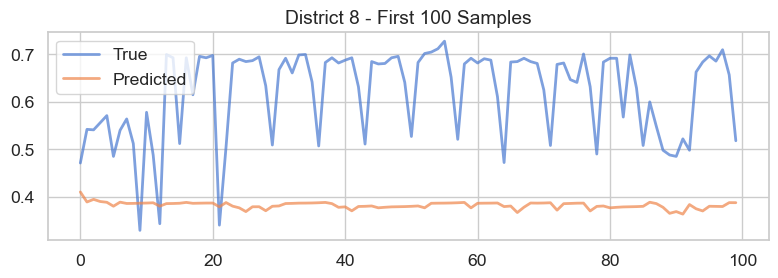

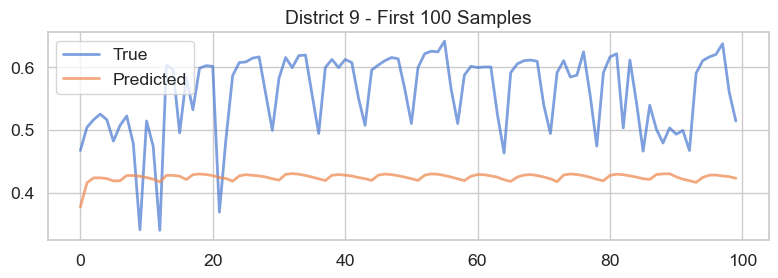

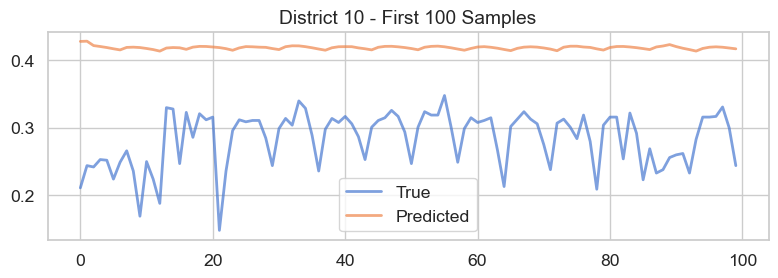

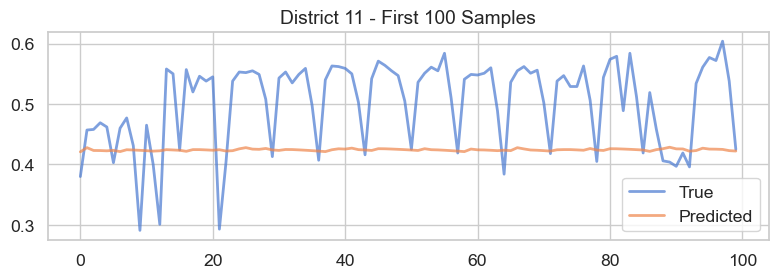

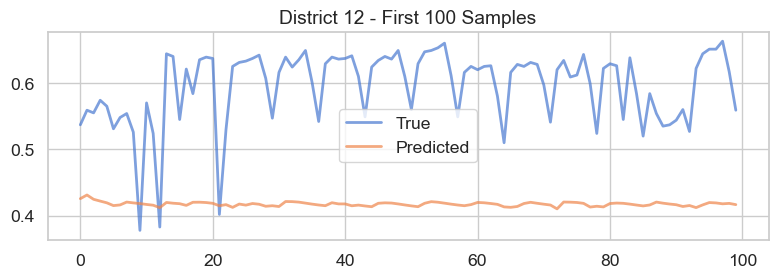

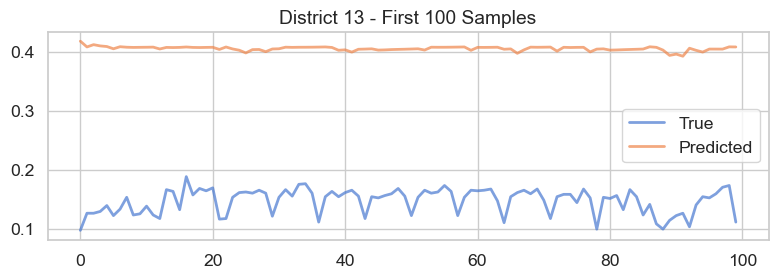

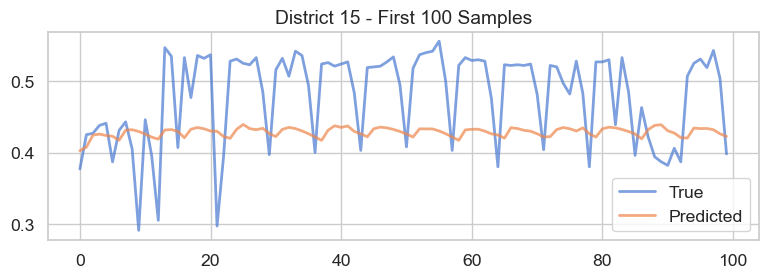

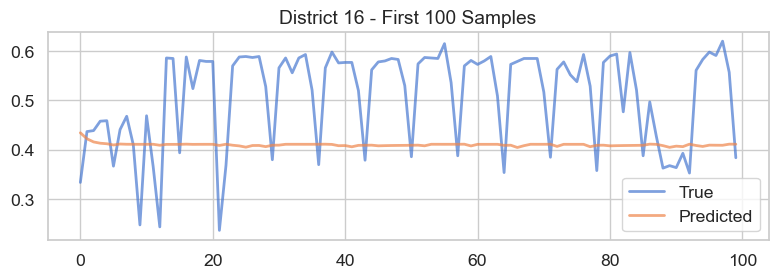

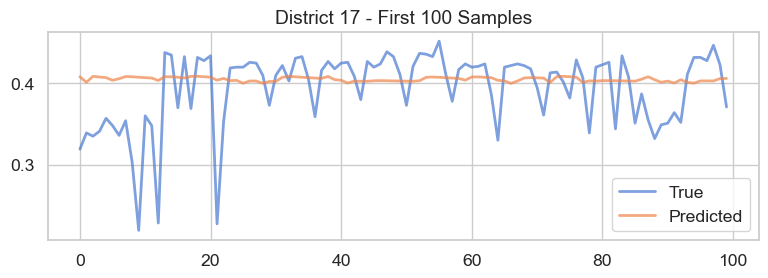

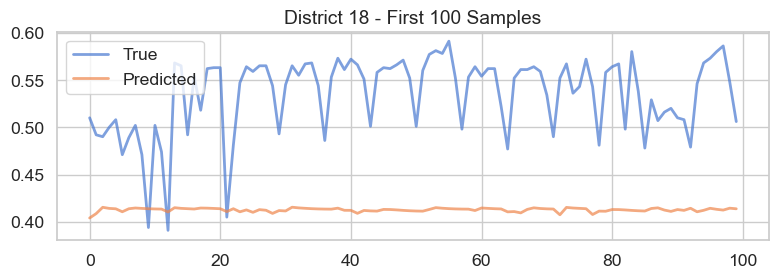

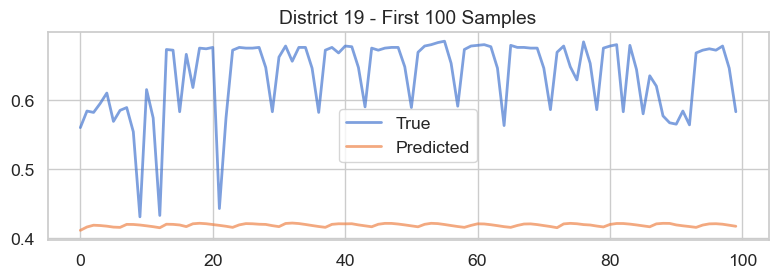

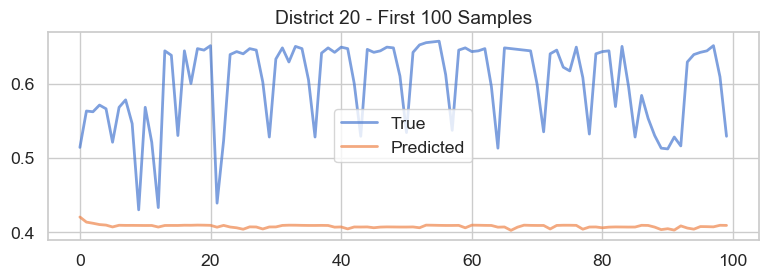

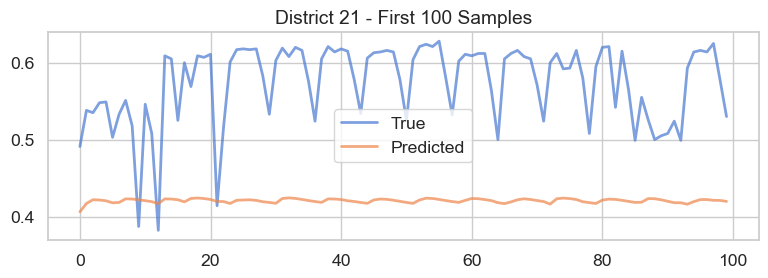

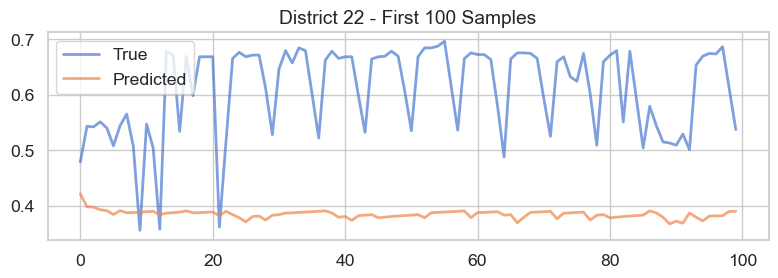

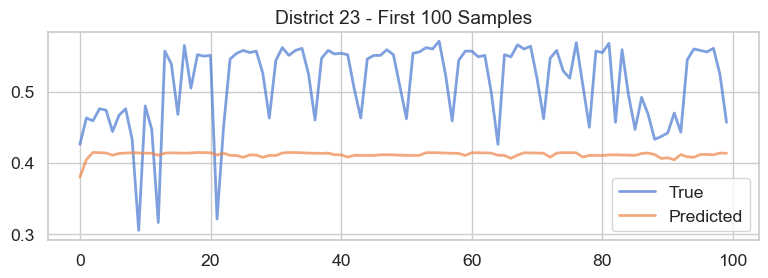

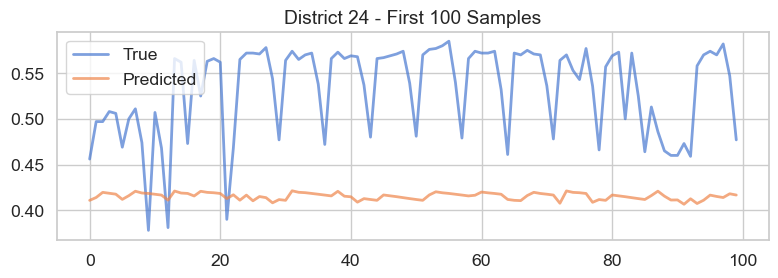

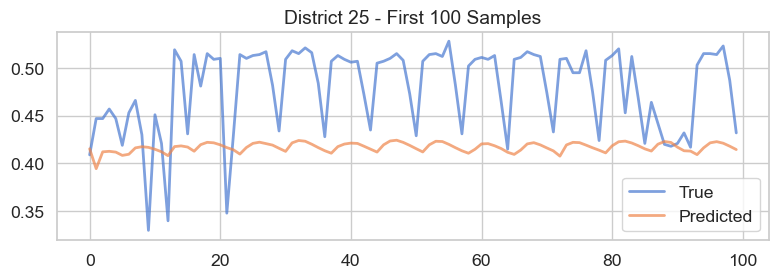

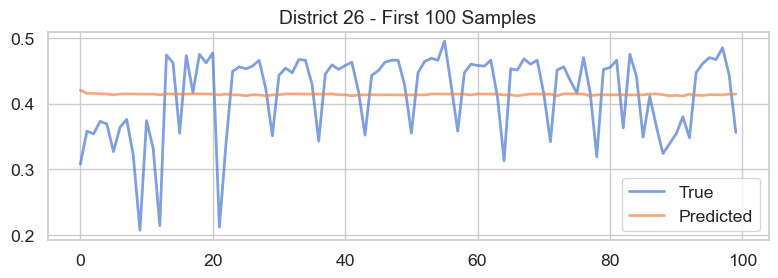

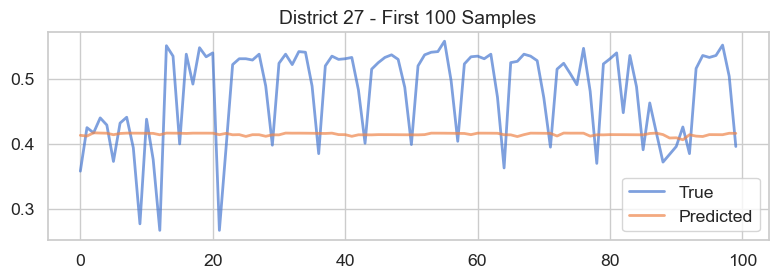

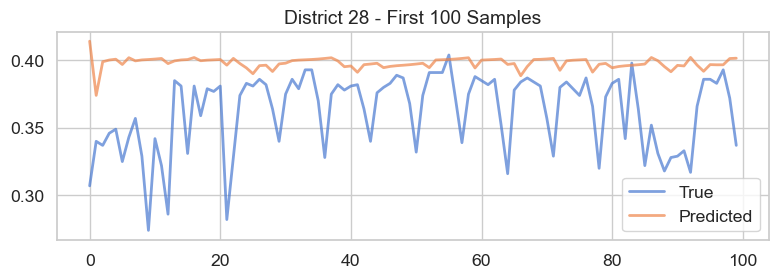

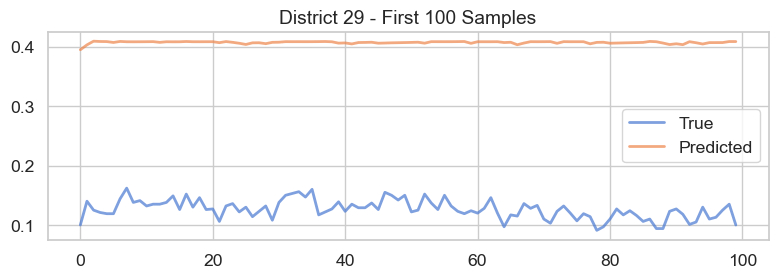

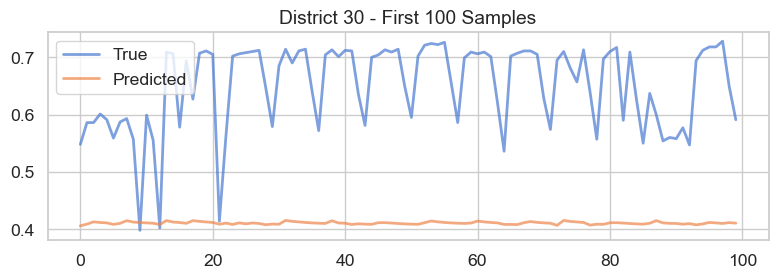

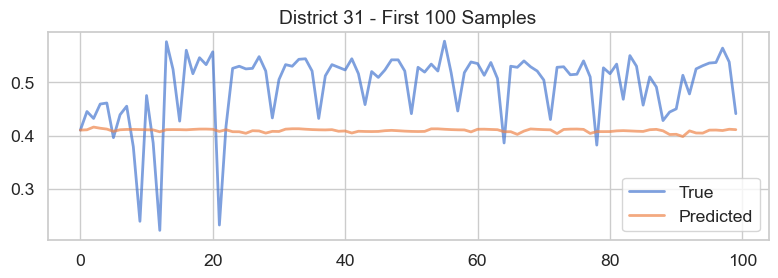

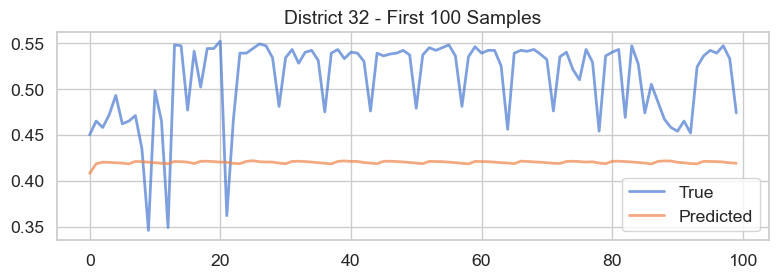

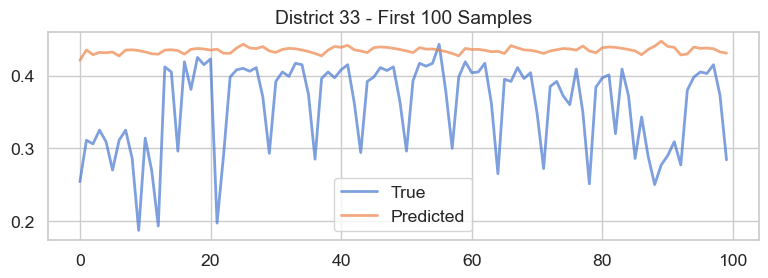

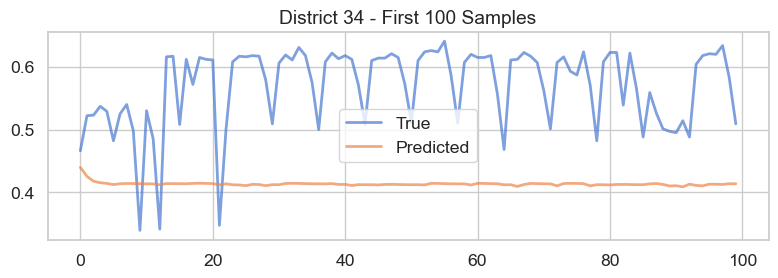

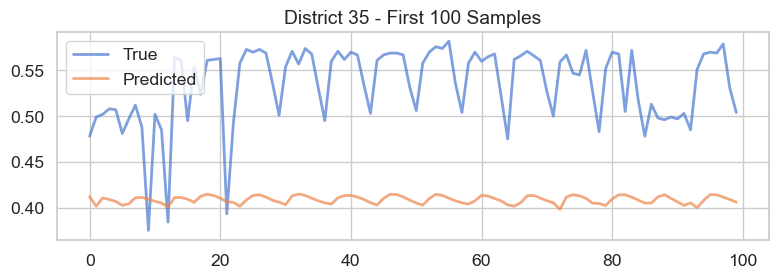

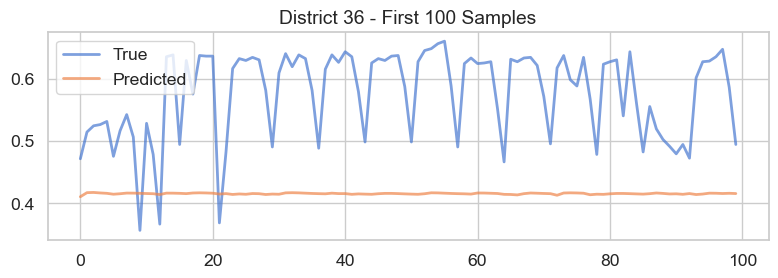

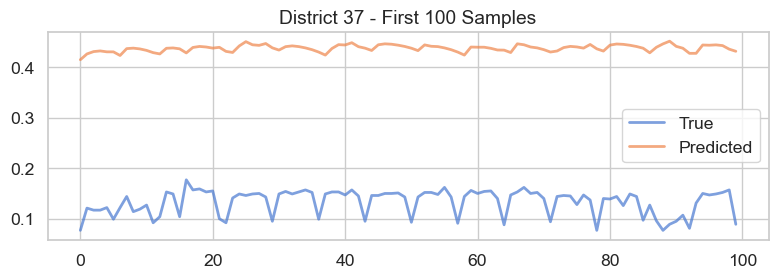

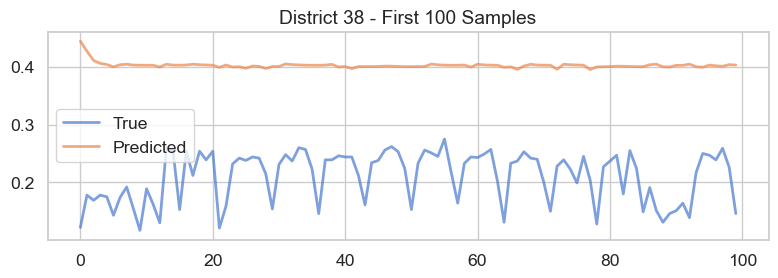

In [11]:
all_results = []

model.eval()
districts = np.unique(districts_seq)

for district in districts:
    idxs = districts_seq == district
    X_d = Xs_seq[idxs]
    y_d = ys_seq[idxs]

    if len(X_d) == 0:
        continue

    Xb = torch.tensor(X_d, dtype=torch.float32).to(model.device if hasattr(model, "device") else "cpu")
    with torch.no_grad():
        preds = model(Xb).cpu().squeeze().numpy()
    preds_inv = sy.inverse_transform(preds.reshape(-1, 1)).flatten()
    y_true_inv = sy.inverse_transform(y_d.reshape(-1, 1)).flatten()

    for i in range(len(preds_inv)):
        all_results.append({
            "district": district,
            "seq_idx": i,
            "true": y_true_inv[i],
            "predicted": preds_inv[i]
        })

    plt.figure(figsize=(8, 3))
    plt.plot(y_true_inv[:100], label="True", alpha=0.7, linewidth=2)
    plt.plot(preds_inv[:100], label="Predicted", alpha=0.7, linewidth=2)
    plt.title(f"District {district} - First 100 Samples")
    plt.legend()
    plt.tight_layout()
    plt.show()